In [1]:
# ============================================
# Standard library imports
# ============================================

import sys
import re
import logging
import warnings
from pathlib import Path

from IPython.display import display

warnings.filterwarnings("ignore")


# ============================================
# Numeric / statistics
# ============================================

import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr


# ============================================
# Machine learning / multivariate analysis
# ============================================

from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
)


# ============================================
# Plotting / visualization
# ============================================

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

import seaborn as sns

# Optional: raincloud plot
try:
    import ptitprince as pt
    HAS_PTITPRINCE = True
except ImportError:
    HAS_PTITPRINCE = False
    print("ptitprince is not installed. RainCloud plots will be skipped.")


# ============================================
# Version info
# ============================================

print(f"python  = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas  = {pd.__version__}")
print(f"numpy   = {np.__version__}")
print(f"scipy   = {scipy.__version__}")

if HAS_PTITPRINCE:
    print("ptitprince imported successfully")


# ============================================
# Logging
# ============================================

logging.root.handlers = []

stream_handler = logging.StreamHandler(sys.stderr)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)

logger = logging.getLogger(__name__)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

python  = 3.11.15
pandas  = 2.3.3
numpy   = 2.4.6
scipy   = 1.17.1
ptitprince imported successfully


In [2]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=12,
    title_fontsize=14,
    label_fontsize=12,
    tick_fontsize=11,
    legend_fontsize=12,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

# ============================================
# Plot helper functions
# ============================================

def species_palette():
    return [
        SPECIES_INFO["AT21"]["color"],
        SPECIES_INFO["NB21"]["color"],
        SPECIES_INFO["OS21"]["color"],
    ]


def outside_legend(
    ax,
    *,
    title="Species",
    n_items=3,
    x=1.02,
    y=1.00,
):
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:n_items],
        labels[:n_items],
        title=title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(x, y),
        borderaxespad=0,
    )

    return ax

In [3]:
# ============================================
# Feature annotation helpers
# ============================================

def feature_region(feature):

    if feature.startswith("5'UTR."):
        return "5'UTR"

    if feature.startswith("3'UTR."):
        return "3'UTR"

    if feature.startswith("CDS."):
        return "CDS"

    return "mRNA"


def feature_type(col):

    if col.endswith(".Length"):
        return "Length"

    if (
        ".uAUG" in col
        or ".uORF" in col
        or ".dAUG" in col
        or ".dORF" in col
    ):
        return "ORF_nonCDS"

    if col.endswith(".MFE"):
        return "RNA_structure_MFE"

    if ".wobble_pct_" in col:
        return "Wobble"

    if ".aa_pct_" in col:
        return "Amino_acid_composition"

    if ".dicodon_" in col:
        return "Dicodon"

    if re.search(r"\.[A-Z][a-z]{2}-[AUGC]{3}$", col):
        return "Codon_usage"

    if col.endswith("-freq"):
        return "Nucleotide_kmer_freq"

    return "Other"

In [4]:
# ============================================
# Load all feature importance tables
# ============================================

RESULT_DIR = Path("../results")

files = [
    ("AT21", "RF",   RESULT_DIR / "rf"   / "AT21.rf.feature_importance.tsv"),
    ("AT21", "LGBM", RESULT_DIR / "lgbm" / "AT21.lgbm.feature_importance.tsv"),

    ("NB21", "RF",   RESULT_DIR / "rf"   / "NB21.rf.feature_importance.tsv"),
    ("NB21", "LGBM", RESULT_DIR / "lgbm" / "NB21.lgbm.feature_importance.tsv"),

    ("OS21", "RF",   RESULT_DIR / "rf"   / "OS21.rf.feature_importance.tsv"),
    ("OS21", "LGBM", RESULT_DIR / "lgbm" / "OS21.lgbm.feature_importance.tsv"),
]

dfs = []

for species, model, path in files:

    df = pd.read_csv(path, sep="\t")

    df["species"] = species
    df["model"] = model

    dfs.append(df)

importance_all = pd.concat(
    dfs,
    ignore_index=True,
)

print(importance_all.shape)

display(
    importance_all.head()
)

(2663, 5)


,species,model,rank,feature,importance
0,AT21,RF,1,CDS.G-freq,0.042472
1,AT21,RF,2,5'UTR.MFE,0.027173
2,AT21,RF,3,CDS.GG-freq,0.018439
3,AT21,RF,4,5'UTR.A-freq,0.016365
4,AT21,RF,5,CDS.AU-freq,0.015806


In [6]:
# ============================================
# Choose one model for SSS analysis
# ============================================

TARGET_MODEL = "LGBM"   # change to "RF" later if needed

importance_one = (
    importance_all[
        importance_all["model"] == TARGET_MODEL
    ]
    .copy()
)

importance_df = (
    importance_one
    .pivot_table(
        index="feature",
        columns="species",
        values="importance",
        aggfunc="mean",
    )
    .fillna(0)
)

importance_df = importance_df[
    [
        "AT21",
        "NB21",
        "OS21",
    ]
]

print(importance_df.shape)

display(
    importance_df.head()
)

(449, 3)


species,AT21,NB21,OS21
feature,,,
3'UTR.A-freq,6.0,5.0,16.0
3'UTR.AA-freq,14.0,4.0,16.0
3'UTR.AAA-freq,3.0,9.0,10.0
3'UTR.AAC-freq,14.0,5.0,10.0
3'UTR.AAG-freq,11.0,9.0,6.0


In [7]:
# ============================================
# Species Specificity Score (SSS)
# General version for one ML model
# ============================================

def compute_sss(
    importance_df,
):

    AT = importance_df["AT21"]
    NB = importance_df["NB21"]
    OS = importance_df["OS21"]

    sss_df = pd.DataFrame(
        index=importance_df.index
    )

    # ----------------------------------------
    # Species Specificity Score
    # ----------------------------------------

    sss_df["AT_SSS"] = np.sqrt(
        (AT - NB) ** 2
        +
        (AT - OS) ** 2
    )

    sss_df["NB_SSS"] = np.sqrt(
        (NB - AT) ** 2
        +
        (NB - OS) ** 2
    )

    sss_df["OS_SSS"] = np.sqrt(
        (OS - AT) ** 2
        +
        (OS - NB) ** 2
    )

    # ----------------------------------------
    # Delta = direction only
    # ----------------------------------------

    sss_df["AT_Delta"] = (
        AT - (NB + OS) / 2
    )

    sss_df["NB_Delta"] = (
        NB - (AT + OS) / 2
    )

    sss_df["OS_Delta"] = (
        OS - (AT + NB) / 2
    )

    # ----------------------------------------
    # Annotation
    # ----------------------------------------

    sss_df["Feature"] = sss_df.index

    sss_df["Feature_type"] = (
        sss_df["Feature"]
        .apply(feature_type)
    )

    sss_df["Region"] = (
        sss_df["Feature"]
        .apply(feature_region)
    )

    return sss_df


sss_df = compute_sss(
    importance_df
)

display(
    sss_df.head()
)

,AT_SSS,NB_SSS,OS_SSS,AT_Delta,NB_Delta,OS_Delta,Feature,Feature_type,Region
feature,,,,,,,,,
3'UTR.A-freq,10.049876,11.045361,14.866069,-4.5,-6.0,10.5,3'UTR.A-freq,Nucleotide_kmer_freq,3'UTR
3'UTR.AA-freq,10.198039,15.620499,12.165525,4.0,-11.0,7.0,3'UTR.AA-freq,Nucleotide_kmer_freq,3'UTR
3'UTR.AAA-freq,9.219544,6.082763,7.071068,-6.5,2.5,4.0,3'UTR.AAA-freq,Nucleotide_kmer_freq,3'UTR
3'UTR.AAC-freq,9.848858,10.295630,6.403124,6.5,-7.0,0.5,3'UTR.AAC-freq,Nucleotide_kmer_freq,3'UTR
3'UTR.AAG-freq,5.385165,3.605551,5.830952,3.5,0.5,-4.0,3'UTR.AAG-freq,Nucleotide_kmer_freq,3'UTR


In [8]:
# ============================================
# Convert SSS table to long format
# ============================================

def sss_to_long(
    sss_df,
):

    sss_long = (
        sss_df
        .melt(
            id_vars=[
                "Feature",
                "Feature_type",
                "Region",
            ],
            value_vars=[
                "AT_SSS",
                "NB_SSS",
                "OS_SSS",
            ],
            var_name="Species",
            value_name="SSS",
        )
    )

    sss_long["Species"] = (
        sss_long["Species"]
        .str.replace(
            "_SSS",
            "",
            regex=False,
        )
    )

    delta_long = (
        sss_df
        .melt(
            id_vars=[
                "Feature",
                "Feature_type",
                "Region",
            ],
            value_vars=[
                "AT_Delta",
                "NB_Delta",
                "OS_Delta",
            ],
            var_name="Species",
            value_name="Delta",
        )
    )

    delta_long["Species"] = (
        delta_long["Species"]
        .str.replace(
            "_Delta",
            "",
            regex=False,
        )
    )

    out = (
        sss_long
        .merge(
            delta_long,
            on=[
                "Feature",
                "Feature_type",
                "Region",
                "Species",
            ],
        )
    )

    out["Enrichment"] = np.where(
        out["Delta"] > 0,
        "Enriched",
        "Depleted",
    )

    return out


sss_long = sss_to_long(
    sss_df
)

display(
    sss_long.head()
)

,Feature,Feature_type,Region,Species,SSS,Delta,Enrichment
0,3'UTR.A-freq,Nucleotide_kmer_freq,3'UTR,AT,10.049876,-4.5,Depleted
1,3'UTR.AA-freq,Nucleotide_kmer_freq,3'UTR,AT,10.198039,4.0,Enriched
2,3'UTR.AAA-freq,Nucleotide_kmer_freq,3'UTR,AT,9.219544,-6.5,Depleted
3,3'UTR.AAC-freq,Nucleotide_kmer_freq,3'UTR,AT,9.848858,6.5,Enriched
4,3'UTR.AAG-freq,Nucleotide_kmer_freq,3'UTR,AT,5.385165,3.5,Enriched


In [9]:
# ============================================
# Keep informative feature classes
# ============================================

keep_feature_types = [
    "Nucleotide_kmer_freq",
    "Length",
    "RNA_structure_MFE",
    "Codon_usage",
    "Amino_acid_composition",
    "Wobble",
]

sss_keep = (
    sss_long[
        sss_long["Feature_type"]
        .isin(keep_feature_types)
    ]
    .copy()
)

display(
    sss_keep.head()
)

,Feature,Feature_type,Region,Species,SSS,Delta,Enrichment
0,3'UTR.A-freq,Nucleotide_kmer_freq,3'UTR,AT,10.049876,-4.5,Depleted
1,3'UTR.AA-freq,Nucleotide_kmer_freq,3'UTR,AT,10.198039,4.0,Enriched
2,3'UTR.AAA-freq,Nucleotide_kmer_freq,3'UTR,AT,9.219544,-6.5,Depleted
3,3'UTR.AAC-freq,Nucleotide_kmer_freq,3'UTR,AT,9.848858,6.5,Enriched
4,3'UTR.AAG-freq,Nucleotide_kmer_freq,3'UTR,AT,5.385165,3.5,Enriched


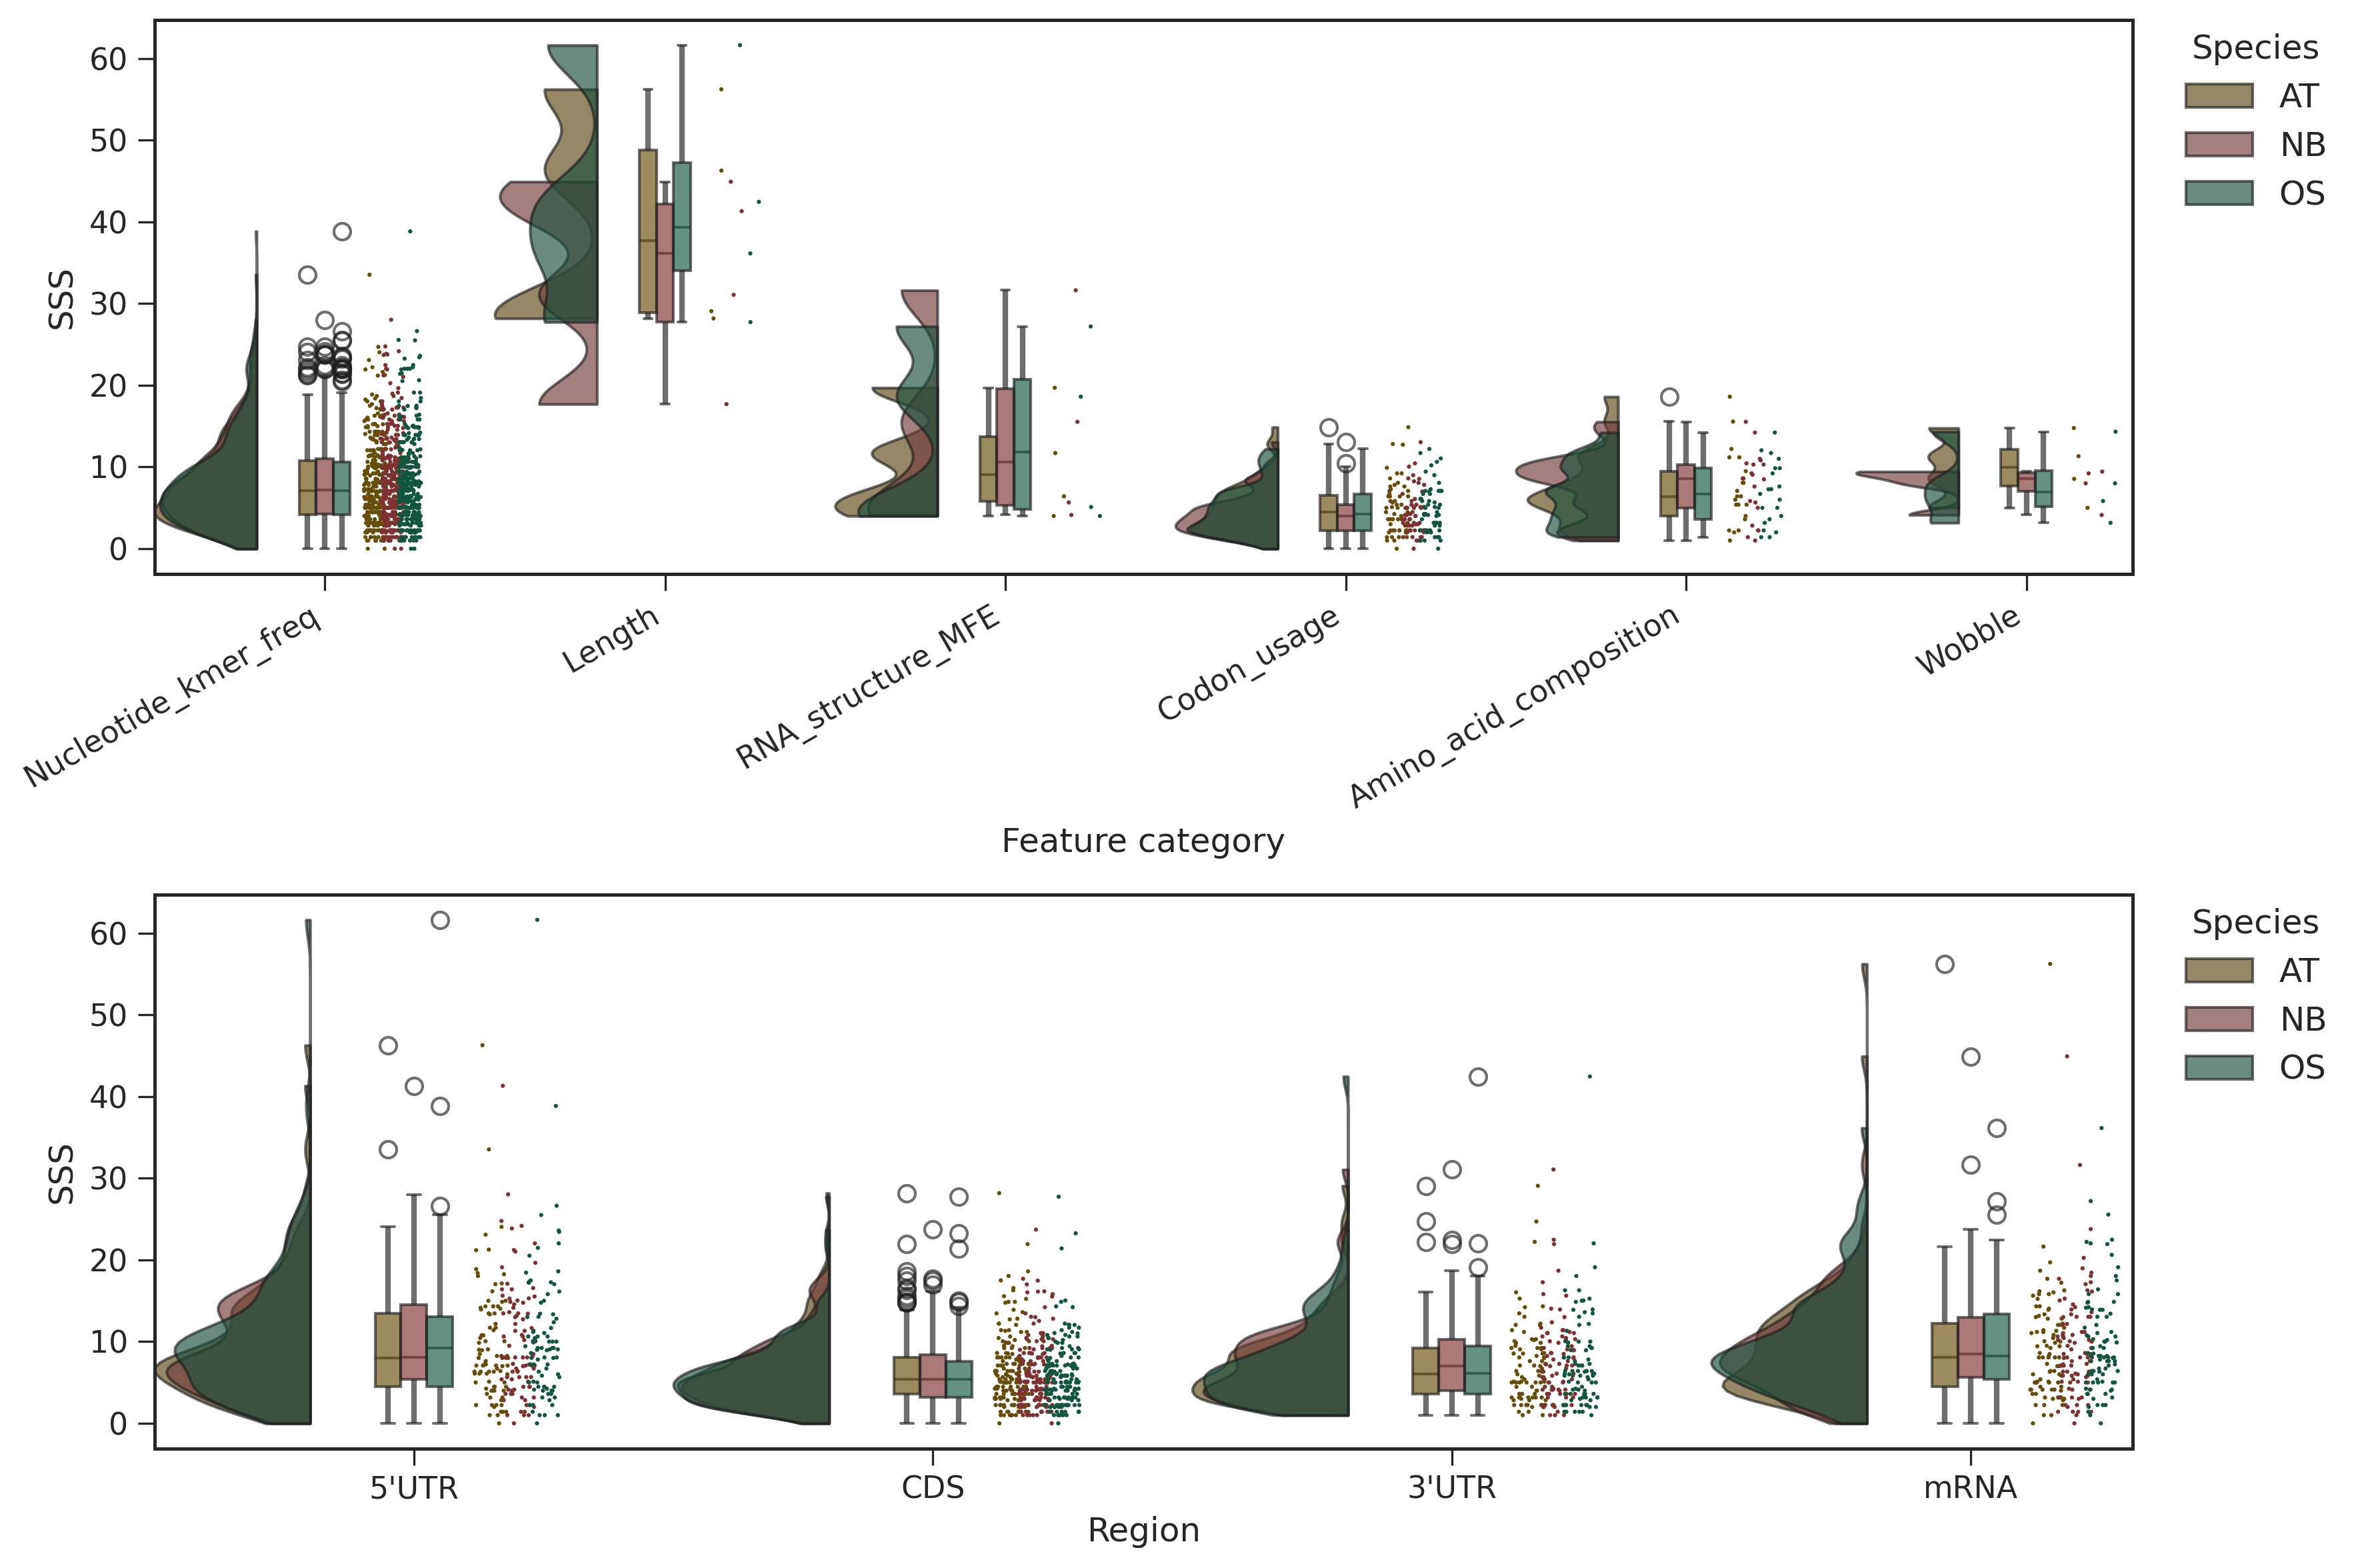

In [10]:
# ============================================
# SSS RainCloud
# Feature type + Region
# ============================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    dpi=_PLOT_CFG["dpi"],
)

# --------------------------------------------
# Feature type
# --------------------------------------------

ax = axes[0]

pt.RainCloud(
    data=sss_keep,
    x="Feature_type",
    y="SSS",
    hue="Species",
    order=keep_feature_types,
    palette=species_palette(),
    bw=0.25,
    width_viol=0.6,
    width_box=0.15,
    orient="v",
    move=0.2,
    alpha=0.65,
    dodge=True,
    point_size=1.5,
    ax=ax,
)

format_axis(
    ax,
    xlabel="Feature category",
    ylabel="SSS",
)

outside_legend(ax)

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

# --------------------------------------------
# Region
# --------------------------------------------

ax = axes[1]

region_order = [
    "5'UTR",
    "CDS",
    "3'UTR",
    "mRNA",
]

pt.RainCloud(
    data=sss_keep,
    x="Region",
    y="SSS",
    hue="Species",
    order=region_order,
    palette=species_palette(),
    bw=0.25,
    width_viol=0.6,
    width_box=0.15,
    orient="v",
    move=0.2,
    alpha=0.65,
    dodge=True,
    point_size=1.5,
    ax=ax,
)

format_axis(
    ax,
    xlabel="Region",
    ylabel="SSS",
)

outside_legend(ax)

plt.tight_layout()
plt.show()